# Notebook Config

In [ ]:
!pip install --upgrade datasets transformers wandb

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 494.8/494.8 kB 31.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 193.6/193.6 kB 18.8 MB/s eta 0:00:00
  Attempting uninstall: fsspec
    Found existing installation: fsspec 2025.3.2
    Uninstalling fsspec-2025.3.2:
      Successfully uninstalled fsspec-2025.3.2
  Attempting uninstall: datasets
    Found existing installation: datasets 2.14.4
    Uninstalling datasets-2.14.4:
      Successfully uninstalled datasets-2.14.4
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
torch 2.6.0+cu124 requires nvidia-cublas-cu12==12.4.5.8; platform_system == "Linux" and platform_machine == "x86_64", but you have nvidia-cublas-cu12 12.5.3.2 which is incompatible.
torch 2.6.0+cu124 requires nvidia-cuda-cupti-cu12==12.4.127; platform_system == "Linux" and platform_machine == "x86_64", but you have nvidia-cuda-cupti-cu12

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import logging
import random
import sys
import os
import traceback
from datetime import datetime

import pandas as pd
import matplotlib.pyplot as plt

from tqdm import tqdm
from datasets import Dataset, load_dataset
from torch.utils.data import DataLoader

from sentence_transformers import SentenceTransformer, models, util, InputExample
from sentence_transformers.evaluation import EmbeddingSimilarityEvaluator
from sentence_transformers.losses import DenoisingAutoEncoderLoss, CosineSimilarityLoss
from sentence_transformers.similarity_functions import SimilarityFunction
from sentence_transformers.trainer import SentenceTransformerTrainer
from sentence_transformers.training_args import SentenceTransformerTrainingArguments

# Set the log level to INFO to get more information
logging.basicConfig(format="%(asctime)s - %(message)s", datefmt="%Y-%m-%d %H:%M:%S", level=logging.INFO)

# Output path
output_path = r"/content/drive/MyDrive/Colab Notebooks/NLP/fine-tune-embedding-model/iterations"

import wandb
wandb.init(mode="disabled")

In [ ]:
# Define training parameters
model_name = "all-MiniLM-L6-v2"
train_batch_size = 16
num_epochs = 1
max_seq_length = 128

output_dir = f"{output_path}/training_tsdae-{model_name.replace('/', '-')}-{train_batch_size}-{datetime.now().strftime('%Y-%m-%d_%H-%M-%S')}"

# Data

In [ ]:
# --------------------------
# Load the dataset
# --------------------------

import kagglehub

# Dataset - https://www.kaggle.com/datasets/chaitanyakck/medical-text
path = kagglehub.dataset_download("chaitanyakck/medical-text")

train_sentences = []

with open(f'{path}/train.dat', 'r') as file:
    for line in file:
        train_sentences.append(line)

with open(f'{path}/test.dat', 'r') as file:
    for line in file:
        train_sentences.append(line)

print(len(train_sentences))

100%|██████████| 11.6M/11.6M [00:01<00:00, 7.23MB/s]

Extracting files...


28880


In [ ]:
train_sentences[50]

'1\tRole of percutaneous fine-needle aspiration biopsy in suspected intrathoracic malignancy. Percutaneous fine-needle aspiration (PFNA) biopsy is an accepted technique for the diagnosis of suspected intrathoracic malignancy, but the appropriate indications for its use have not been clearly defined. To help establish guidelines, we performed a retrospective analysis of 188 patients who underwent PFNA biopsy for suspected intrathoracic malignancy. Biopsy led to a diagnosis in 72% (135/188) of the patients, but in 27% (50/188) samples were inadequate for cytological diagnosis, and in 2% (3/188) samples were adequate but failed to yield a diagnosis. Fifty-three patients underwent surgical intervention, thus allowing histological confirmation of the cytological diagnosis. In patients with a diagnosis from PFNA biopsy, operation confirmed malignancy in 97% (37/38) and a specific cell type in 79% (30/38). In patients without a diagnosis after biopsy, a malignancy was found in 73% (11/15) at 

# Example Check

In [ ]:
# -----------------------------------------------------------------------------------
# The two sentences are highly similar in meaning, though not identical in wording.
# There's a significant difference in the cosine similarity between the two sentences
# when using a generic model. This builds a case for domain adaptation.
# -----------------------------------------------------------------------------------

model_generic = SentenceTransformer('all-MiniLM-L6-v2')
model_med = SentenceTransformer('pritamdeka/S-PubMedBert-MS-MARCO')

# Two similar sentences
sentence1 = "Inadequate cytological samples were obtained in 27% of PFNA procedures, with a subset of these patients later confirmed to harbor intrathoracic malignancies."
sentence2 = "A substantial proportion of non-diagnostic PFNA samples were ultimately associated with malignancies confirmed via surgical resection"

# Compute cosine similarity
cos_sim_generic = util.cos_sim(
    model_generic.encode(sentence1, convert_to_tensor=True),
    model_generic.encode(sentence2, convert_to_tensor=True)
  )

cos_sim_med = util.cos_sim(
    model_med.encode(sentence1, convert_to_tensor=True),
    model_med.encode(sentence2, convert_to_tensor=True)
  )

print(f"Cosine similarity from generic model: {cos_sim_generic.item():.2f}")
print(f"Cosine similarity from domain adapted (medical) model: {cos_sim_med.item():.2f}")

# Cosine similarity from generic model: 0.76
# Cosine similarity from domain adapted (medical) model: 0.95

Cosine similarity from generic model: 0.76
Cosine similarity from domain adapted (medical) model: 0.95


# Token Limit Check

In [ ]:
# ------------------------------------------------------------------------------------------------------------
# max_seq_length is declared 128 and sentences having tokens longer than 128 will be truncated. If significant
# portion of the data is above 128 tokens then ideally should increase the max_seq_length or chunk the data
# into smaller pieces
# ------------------------------------------------------------------------------------------------------------

from transformers import AutoTokenizer
tokenizer = AutoTokenizer.from_pretrained("sentence-transformers/all-MiniLM-L6-v2")
print("Token limit:", tokenizer.model_max_length)

lengths = [len(tokenizer.tokenize(s)) for s in train_sentences]
print(f"Max: {max(lengths)}, Mean: {sum(lengths)//len(lengths)}")

Token indices sequence length is longer than the specified maximum sequence length for this model (622 > 512). Running this sequence through the model will result in indexing errors


Token limit: 512
Max: 899, Mean: 283


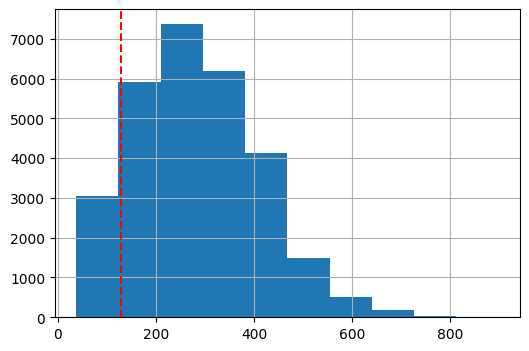

In [ ]:
plt.figure(figsize = (6, 4))
pd.DataFrame(data = lengths, columns = ['token_len'])['token_len'].hist()
plt.axvline(x=max_seq_length, color='r', linestyle='--')
plt.show()

In [ ]:
# from transformers import AutoTokenizer
# from nltk.tokenize import sent_tokenize
# import nltk

# nltk.download("punkt", quiet=True)
# tokenizer = AutoTokenizer.from_pretrained(f"sentence-transformers/{model_name}")

# # Function to split one document into ≤128-token segments
# def split_text_to_token_segments(text, tokenizer=tokenizer, max_tokens=max_seq_length):

#   sentences = sent_tokenize(text)
#   segments = []
#   current_segment = ""

#   for sentence in sentences:
#       tentative_segment = (current_segment + " " + sentence).strip()
#       token_count = len(tokenizer.tokenize(tentative_segment))

#       if token_count <= max_tokens:
#           current_segment = tentative_segment
#       else:
#           if current_segment:
#               segments.append(current_segment.strip())
#           current_segment = sentence  # start new segment

#   if current_segment:
#       segments.append(current_segment.strip())

#   return segments

# # Process all texts into training-ready chunks
# corpus = []

# for doc in tqdm(train_sentences, desc="Splitting into segments"):
#     segments = split_text_to_token_segments(doc)
#     corpus.extend(segments)

# print(len(train_sentences), len(corpus))

# Domain Adaptation with TSDAE

In [ ]:
def noise_transform(batch, del_ratio=0.6):
    """
    Applies noise by randomly deleting words.
    Args:
        batch (Dict[str, List[str]]): A dictionary with the structure
            {column_name: [string1, string2, ...]}, where each list contains
            the batch data for the respective column.
        del_ratio (float): The ratio of words to delete. Defaults to 0.6.
    """
    import nltk
    from nltk import word_tokenize
    from nltk.tokenize.treebank import TreebankWordDetokenizer

    nltk.download('punkt_tab', quiet=True)

    assert 0.0 <= del_ratio < 1.0, "del_ratio must be in the range [0, 1)"
    assert isinstance(batch, dict) and "text" in batch, "batch must be a dictionary with a 'text' key."

    noisy_texts = []
    for text in batch["text"]:
        words = word_tokenize(text)
        n = len(words)
        if n == 0:
            noisy_texts.append(text)
            continue

        kept_words = [word for word in words if random.random() < del_ratio]
        # Guarantee that at least one word remains
        if len(kept_words) == 0:
            noisy_texts.append(random.choice(words))
            continue

        noisy_texts.append(TreebankWordDetokenizer().detokenize(kept_words))
    return {"noisy": noisy_texts, "text": batch["text"]}

In [ ]:
# --------------------------
# Data prep for TSDAE
# --------------------------

dataset = Dataset.from_dict({"text": train_sentences})
dataset.set_transform(transform=lambda batch: noise_transform(batch), columns=["text"], output_all_columns=True)
dataset = dataset.train_test_split(test_size=2000)

train_dataset = dataset["train"]
eval_dataset = dataset["test"]

print(train_dataset)
print(eval_dataset)
print(train_dataset[50])

Dataset({
    features: ['text'],
    num_rows: 26880
})
Dataset({
    features: ['text'],
    num_rows: 2000
})
{'noisy': 'Intractable complex partial seizures with temporal lobe encephalocele and meningoangiomatosis: case Occult congenital temporal lobe rarely reported in with intractable complex partial The four reported cases were unsuspected of partial age . onset to right lobe . neuroimaging a fossa and inferior of temporal examination the encephalocele prominent features meningoangiomatosis . this to the first case of temporal lobe encephalocele and diagnosed, the first also to associated with meningoangiomatosis . relevant literature on and on temporal lobe encephalocele a cause of epilepsy', 'text': '4\tIntractable complex partial seizures associated with occult temporal lobe encephalocele and meningoangiomatosis: a case report. Occult congenital temporal lobe encephalocele has rarely been reported in association with medically intractable complex partial seizures. The four pr

In [ ]:
# --------------------------
# Load model + loss
# --------------------------

model = SentenceTransformer(model_name)
model.max_seq_length = max_seq_length

train_loss = DenoisingAutoEncoderLoss(model, decoder_name_or_path=model_name, tie_encoder_decoder=True)

/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Some weights of BertLMHeadModel were not initialized from the model checkpoint at sentence-transformers/all-MiniLM-L6-v2 and are newly initialized: ['bert.encoder.layer.0.crossattention.output.LayerNorm.bias', 'bert.encoder.layer.0.crossattention.output.LayerNorm.weight', 'bert.encoder.layer.0.crossattention.output.dense.bias', 'bert.encoder.layer.0.crossattention.output.dense.weight', 'bert.encoder.layer.0.crossattention.self.key.bias', 'bert.encoder.layer.0.crossattention.self.key.weight', 'bert.encoder.layer.0.crossattention.self.query.bias', 'bert.encoder.layer.0.crossattention.self.query.weight', 'bert.encoder.layer.0.crossattention.self.value.bias', 'bert.encoder.layer.0.crossattention.self.value.weight', 'bert.encoder.layer.1.crossattention.output.LayerNorm.bias', 'bert.encoder.layer.1.crossattention.output.LayerNorm.weight', 'bert.encoder.layer.1.crossattention.output.dense.bias', 'bert.encoder.layer.1.crossattention.output.dense.weight', 'bert.encoder.layer.1.crossattention.se

In [ ]:
# --------------------------
# Training arguments
# --------------------------

args = SentenceTransformerTrainingArguments(
    output_dir=output_dir,
    num_train_epochs=num_epochs,
    per_device_train_batch_size=train_batch_size,
    per_device_eval_batch_size=train_batch_size,
    warmup_ratio=0.1,
    fp16=True,  # Set to False if you get an error that your GPU can't run on FP16
    bf16=False,  # Set to True if you have a GPU that supports BF16
    eval_strategy="steps",
    eval_steps=500,
    report_to="none"
)

In [ ]:
# --------------------------
# Trainer + Train
# --------------------------

trainer = SentenceTransformerTrainer(
    model=model,
    args=args,
    train_dataset=train_dataset,
    eval_dataset=eval_dataset,
    loss=train_loss,
)

trainer.train()

Step,Training Loss,Validation Loss
500,5.984300,5.071041
1000,4.790700,4.596333
1500,4.491700,4.433764


TrainOutput(global_step=1680, training_loss=5.016817401704334, metrics={'train_runtime': 426.9578, 'train_samples_per_second': 62.957, 'train_steps_per_second': 3.935, 'total_flos': 0.0, 'train_loss': 5.016817401704334, 'epoch': 1.0})

In [ ]:
# --------------------------
# Save final model
# --------------------------

final_output_dir = f"{output_dir}/fine_tuned_tsdae"
model.save(final_output_dir)

In [ ]:
cos_sim_fine_tuned = util.cos_sim(
    model.encode(sentence1, convert_to_tensor=True),
    model.encode(sentence2, convert_to_tensor=True)
  )

print(f"Cosine similarity from fine-tuned model: {cos_sim_fine_tuned.item():.2f}")
# Cosine similarity from fine-tuned model: 0.79

Cosine similarity from fine-tuned model: 0.79


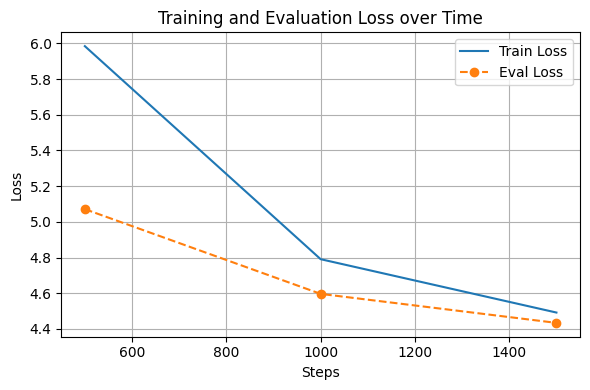

In [ ]:
log_history = trainer.state.log_history
train_loss_values = []
eval_loss_values = []
steps = []

for log in log_history:
    if 'loss' in log:
        train_loss_values.append(log['loss'])
        steps.append(log['step'])
    elif 'eval_loss' in log:
        eval_loss_values.append(log['eval_loss'])

eval_steps = [log['step'] for log in log_history if 'eval_loss' in log]

plt.figure(figsize=(6, 4))
plt.plot(steps[:len(train_loss_values)], train_loss_values, label='Train Loss')
plt.plot(eval_steps, eval_loss_values, label='Eval Loss', linestyle='--', marker='o')
plt.xlabel('Steps')
plt.ylabel('Loss')
plt.title('Training and Evaluation Loss over Time')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# Supervised Fine-Tuning

In [ ]:
# -----------------------------------------------
# Fine-tune the TSDAE-adapted model on a sentence
# similarity task using a supervised dataset
# -----------------------------------------------

# Load dataset
nq_dataset = load_dataset("sentence-transformers/natural-questions", split="train[:10000]")

# Convert to SentenceTransformer format
train_examples = []
for row in nq_dataset:
    question = row['query']
    answer = row['answer']
    train_examples.append(InputExample(texts=[question, answer], label=1.0))


train_dataloader = DataLoader(train_examples, shuffle=True, batch_size=16)
train_loss = CosineSimilarityLoss(model=model)

In [ ]:
model.fit(train_objectives=[(train_dataloader, train_loss)],
          epochs=1,
          warmup_steps=100)

In [ ]:
model.save(f"{output_dir}/final-medical-similarity-model")

In [2]:
cos_sim_fine_tuned = util.cos_sim(
    model.encode(sentence1, convert_to_tensor=True),
    model.encode(sentence2, convert_to_tensor=True)
  )

print(f"Cosine similarity from fine-tuned model: {cos_sim_fine_tuned.item():.2f}")
# Cosine similarity from fine-tuned model: 1.00

Cosine similarity from fine-tuned model: 1.00


In [1]:
random_sentence = "This is random sentence. Take a moment now to check your account activity and secure your account."

print(util.cos_sim(
    model.encode(sentence1, convert_to_tensor=True),
    model.encode(random_sentence, convert_to_tensor=True)
).item())

# A similary of 1 between two unrelated sentences suggests that the model has suffered from overfitting or embedding collapse.

0.9993076324462891
